# Spending Forecast — Prophet vs LSTM

Google Colab notebook for forecasting future daily spending from historical transaction data.

**Goal:** compare a simple classical time-series model (Prophet) with a neural-network model (LSTM), evaluate both on unseen historical data, and generate a 30-day spending forecast.


In [6]:
!pip -q install prophet kagglehub tensorflow scikit-learn pandas numpy matplotlib


In [7]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 1. Load historical transaction data

The notebook first tries the Kaggle Personal Finance Dataset used in the WealthWise ML work. If it cannot be downloaded, a synthetic two-year spending history is generated automatically.

In [8]:
def create_synthetic_data(days=900):
    rng = np.random.default_rng(SEED)
    dates = pd.date_range('2024-01-01', periods=days, freq='D')
    t = np.arange(days)
    trend = 900 + 0.45 * t
    weekly = 180 * np.sin(2 * np.pi * t / 7)
    monthly = 220 * np.sin(2 * np.pi * t / 30.5)
    noise = rng.normal(0, 120, days)
    amount = np.maximum(50, trend + weekly + monthly + noise)
    return pd.DataFrame({'Date': dates, 'Amount': amount})


df = None
try:
    import kagglehub
    path = kagglehub.dataset_download('saraswathyyy/personal-finance-dataset')
    files = glob.glob(os.path.join(path, '**', '*.csv'), recursive=True)
    if files:
        df = pd.read_csv(files[0])
        print('Loaded Kaggle dataset:', files[0])
except Exception as e:
    print('Kaggle download failed:', str(e)[:200])

if df is None:
    print('Using synthetic fallback dataset.')
    df = create_synthetic_data()

print('Shape:', df.shape)
display(df.head())
print('Columns:', df.columns.tolist())


Using Colab cache for faster access to the 'personal-finance-dataset' dataset.
Loaded Kaggle dataset: /kaggle/input/personal-finance-dataset/personal_finance_dataset_8000_extended.csv
Shape: (8000, 15)


,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay
0,2025-04-05,Transaction at IRCTC,20666.49,Travel,Debit Card,Kolkata,Salary,Debit,Mobile,INR,Service,No,Saturday,April,Night
1,2025-12-06,Transaction at Myntra,1919.05,Online Shopping,Net Banking,Hyderabad,Salary,Debit,Desktop,INR,Online Store,Yes,Saturday,December,Evening
2,2025-06-20,Transaction at BigBazaar,2837.68,Grocery,Debit Card,Bangalore,Savings,Debit,Mobile,INR,Retail,No,Friday,June,Evening
3,2025-04-23,Transaction at Property Tax Online,1071.04,Bills,Net Banking,Delhi,Current,Debit,POS Terminal,INR,Service,Yes,Wednesday,April,Afternoon
4,2025-03-06,Transaction at Asus Store,10722.80,Electronics,Debit Card,Mumbai,Current,Debit,Mobile,INR,Retail,Yes,Thursday,March,Evening


Columns: ['Date', 'Description', 'Amount', 'Category', 'PaymentMethod', 'Location', 'AccountType', 'TransactionType', 'DeviceUsed', 'Currency', 'MerchantType', 'LoyaltyProgram', 'Weekday', 'Month', 'TimeOfDay']


## 2. Prepare daily spending series

In [9]:
def find_column(columns, candidates):
    lookup = {str(c).lower().replace(' ', '_'): c for c in columns}
    for c in candidates:
        if c in lookup:
            return lookup[c]
    return None

date_col = find_column(df.columns, ['date','transaction_date','datetime','timestamp','time'])
amount_col = find_column(df.columns, ['amount','transaction_amount','expense','spending','value'])

if date_col is None or amount_col is None:
    raise ValueError(f'Could not identify date/amount columns. Found: {df.columns.tolist()}')

series = df[[date_col, amount_col]].copy()
series.columns = ['ds', 'y']
series['ds'] = pd.to_datetime(series['ds'], errors='coerce')
series['y'] = pd.to_numeric(series['y'], errors='coerce').abs()
series = series.dropna()
series = series.groupby('ds', as_index=False)['y'].sum().sort_values('ds')

print('Date range:', series['ds'].min(), 'to', series['ds'].max())
print('Days:', len(series))

Date range: 2025-01-01 00:00:00 to 2025-12-31 00:00:00
Days: 365


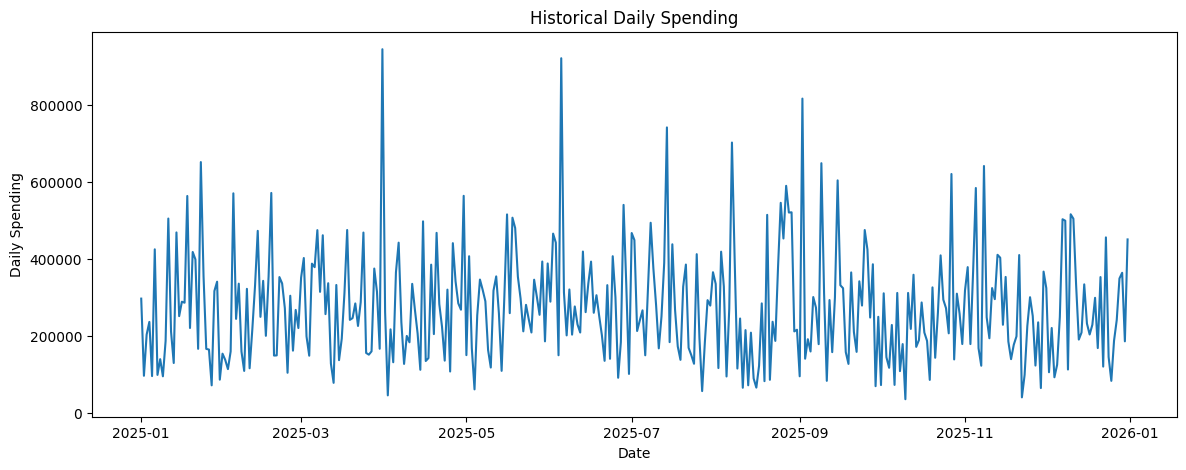

In [10]:
plt.figure(figsize=(14,5))
plt.plot(series['ds'], series['y'])
plt.title('Historical Daily Spending')
plt.xlabel('Date')
plt.ylabel('Daily Spending')
plt.show()


## 3. Train/test split

The last 30 days are held out for final evaluation. Neither model sees these values during training.

In [11]:
HORIZON = 30
if len(series) <= HORIZON + 90:
    raise ValueError('Not enough historical data for a 30-day test and LSTM training window.')

train = series.iloc[:-HORIZON].copy()
test = series.iloc[-HORIZON:].copy()

print('Train:', train['ds'].min(), 'to', train['ds'].max())
print('Test :', test['ds'].min(), 'to', test['ds'].max())


Train: 2025-01-01 00:00:00 to 2025-12-01 00:00:00
Test : 2025-12-02 00:00:00 to 2025-12-31 00:00:00


## 4. Prophet model

In [12]:
prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)
prophet.fit(train)

prophet_test = prophet.predict(test[['ds']])
prophet_pred = np.maximum(0, prophet_test['yhat'].values)

prophet_mae = mean_absolute_error(test['y'], prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test['y'], prophet_pred))

print('Prophet MAE :', round(prophet_mae, 2))
print('Prophet RMSE:', round(prophet_rmse, 2))


Prophet MAE : 116267.28
Prophet RMSE: 136102.55


## 5. LSTM model

In [13]:
LOOKBACK = 30
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train[['y']])

X_lstm, y_lstm = [], []
for i in range(LOOKBACK, len(scaled_train)):
    X_lstm.append(scaled_train[i-LOOKBACK:i, 0])
    y_lstm.append(scaled_train[i, 0])

X_lstm = np.array(X_lstm).reshape(-1, LOOKBACK, 1)
y_lstm = np.array(y_lstm)

lstm = Sequential([
    LSTM(64, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')
lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = lstm.fit(
    X_lstm,
    y_lstm,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    shuffle=False
)


Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 108ms/step - loss: 0.0623 - val_loss: 0.0249
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - loss: 0.0308 - val_loss: 0.0234
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 0.0289 - val_loss: 0.0235
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0273 - val_loss: 0.0226
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.0275 - val_loss: 0.0226
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0269 - val_loss: 0.0224
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0266 - val_loss: 0.0224
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0262 - val_loss: 0.0224
Epoch 9/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0270 - val_loss: 0.0224
Epoch 10/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0269 - val_loss: 0.0223
Epoch 11/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0270 - val_loss: 0.0223
Epoch 12/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0263 - val_loss: 0.0224


In [15]:
# Recursive 30-day LSTM forecast using only historical training values
history_values = scaled_train.flatten().tolist()
lstm_predictions_scaled = []

for _ in range(HORIZON):
    window = np.array(history_values[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    next_value = float(lstm.predict(window, verbose=0)[0, 0])
    lstm_predictions_scaled.append(next_value)
    history_values.append(next_value)

lstm_pred = scaler.inverse_transform(np.array(lstm_predictions_scaled).reshape(-1, 1)).flatten()
lstm_pred = np.maximum(0, lstm_pred)

lstm_mae = mean_absolute_error(test['y'], lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(test['y'], lstm_pred))

print('LSTM MAE :', round(lstm_mae, 2))
print('LSTM RMSE:', round(lstm_rmse, 2))


LSTM MAE : 116606.32
LSTM RMSE: 133971.39


## 6. Compare Prophet vs LSTM

In [16]:
comparison = pd.DataFrame({
    'Model': ['Prophet', 'LSTM'],
    'MAE': [prophet_mae, lstm_mae],
    'RMSE': [prophet_rmse, lstm_rmse]
}).sort_values('RMSE')

comparison.round(2)


,Model,MAE,RMSE
1,LSTM,116606.32,133971.39
0,Prophet,116267.28,136102.55


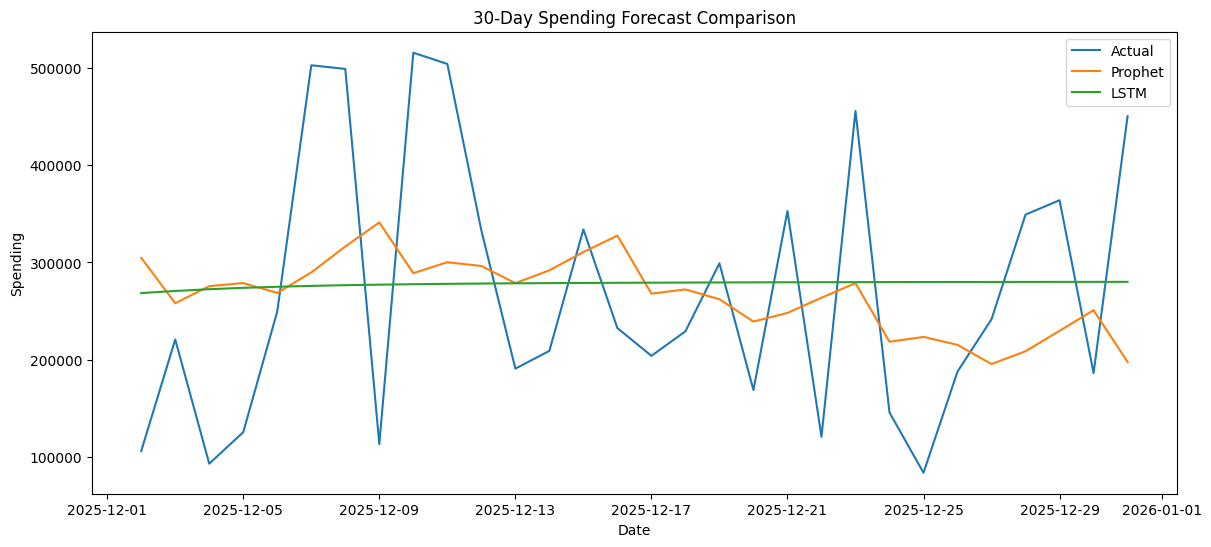

In [17]:
plt.figure(figsize=(14,6))
plt.plot(test['ds'], test['y'].values, label='Actual')
plt.plot(test['ds'], prophet_pred, label='Prophet')
plt.plot(test['ds'], lstm_pred, label='LSTM')
plt.title('30-Day Spending Forecast Comparison')
plt.xlabel('Date')
plt.ylabel('Spending')
plt.legend()
plt.show()


## 7. Train final models on all historical data

After evaluation, retrain both models using all available historical data. The better model can then be selected for the production forecast.

In [18]:
# Final Prophet model
final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)
final_prophet.fit(series)
prophet_future = final_prophet.make_future_dataframe(periods=HORIZON, freq='D')
prophet_forecast = final_prophet.predict(prophet_future)
prophet_future_values = prophet_forecast[prophet_forecast['ds'] > series['ds'].max()][['ds','yhat','yhat_lower','yhat_upper']].copy()
prophet_future_values[['yhat','yhat_lower','yhat_upper']] = prophet_future_values[['yhat','yhat_lower','yhat_upper']].clip(lower=0)

display(prophet_future_values)


,ds,yhat,yhat_lower,yhat_upper
365,2026-01-01,275126.248183,88983.934063,444386.274079
366,2026-01-02,280449.227357,101205.784401,473750.541794
367,2026-01-03,272412.270436,97428.878732,448985.260781
368,2026-01-04,307443.787614,125731.128651,483901.929416
369,2026-01-05,336437.832704,160169.694636,512920.135398
370,2026-01-06,356503.321866,172195.150918,528620.963075
371,2026-01-07,326168.165352,144769.248574,498549.476296
372,2026-01-08,339261.308614,162258.720790,511818.407417
373,2026-01-09,346796.743840,171252.656558,529495.352347
374,2026-01-10,339811.144790,165510.122763,517075.213045


In [19]:
# Final LSTM model using all historical data
full_scaler = MinMaxScaler()
full_scaled = full_scaler.fit_transform(series[['y']])

X_full, y_full = [], []
for i in range(LOOKBACK, len(full_scaled)):
    X_full.append(full_scaled[i-LOOKBACK:i, 0])
    y_full.append(full_scaled[i, 0])

X_full = np.array(X_full).reshape(-1, LOOKBACK, 1)
y_full = np.array(y_full)

final_lstm = Sequential([
    LSTM(64, input_shape=(LOOKBACK, 1)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)
])
final_lstm.compile(optimizer='adam', loss='mse')
final_lstm.fit(X_full, y_full, epochs=30, batch_size=32, verbose=1, shuffle=False)

history_values = full_scaled.flatten().tolist()
lstm_future_scaled = []
for _ in range(HORIZON):
    window = np.array(history_values[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    next_value = float(final_lstm.predict(window, verbose=0)[0,0])
    lstm_future_scaled.append(next_value)
    history_values.append(next_value)

lstm_future_values = full_scaler.inverse_transform(np.array(lstm_future_scaled).reshape(-1,1)).flatten()
lstm_future_values = np.maximum(0, lstm_future_values)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0383
Epoch 2/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0273
Epoch 3/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0270
Epoch 4/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0268
Epoch 5/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0268
Epoch 6/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0267
Epoch 7/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0267
Epoch 8/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0262
Epoch 9/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0257
Epoch 10/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0262
Epoch 11/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0265
Epoch 12/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0262
Epoch 13/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0258
Epoch 14/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0259
Epoch 15/30
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0260
Epoch 16/30
11/

## 8. Select the better model and forecast next 30 days

In [20]:
best_model = comparison.iloc[0]['Model']
print('Selected model:', best_model)

if best_model == 'Prophet':
    final_forecast = prophet_future_values[['ds','yhat','yhat_lower','yhat_upper']].copy()
    final_forecast['forecast'] = final_forecast['yhat']
else:
    final_forecast = pd.DataFrame({
        'ds': prophet_future_values['ds'].values,
        'forecast': lstm_future_values
    })

print('Expected spending for next 30 days:', round(final_forecast['forecast'].sum(), 2))
display(final_forecast)


Selected model: LSTM
Expected spending for next 30 days: 8285163.23


,ds,forecast
0,2026-01-01,275088.779946
1,2026-01-02,276873.559805
2,2026-01-03,277460.004470
3,2026-01-04,277581.852566
4,2026-01-05,277469.874544
5,2026-01-06,277252.976280
6,2026-01-07,276994.191042
7,2026-01-08,276748.899413
8,2026-01-09,276560.475637
9,2026-01-10,276371.808490


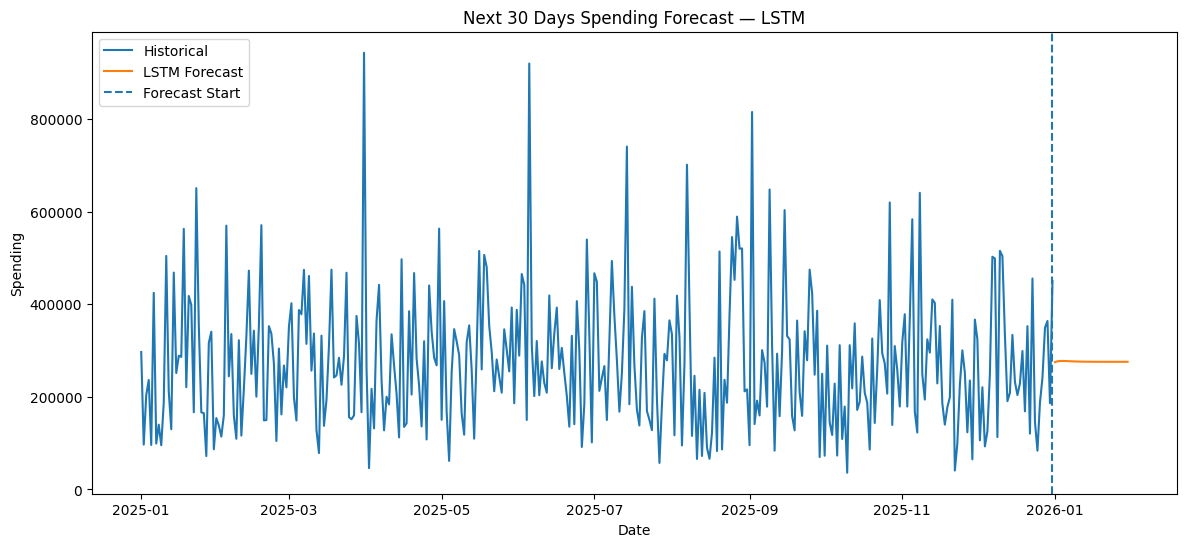

In [21]:
plt.figure(figsize=(14,6))
plt.plot(series['ds'], series['y'], label='Historical')
plt.plot(final_forecast['ds'], final_forecast['forecast'], label=f'{best_model} Forecast')
plt.axvline(series['ds'].max(), linestyle='--', label='Forecast Start')
plt.title(f'Next 30 Days Spending Forecast — {best_model}')
plt.xlabel('Date')
plt.ylabel('Spending')
plt.legend()
plt.show()


## 9. Save artifacts

In [22]:
import joblib
os.makedirs('models', exist_ok=True)

final_forecast.to_csv('spending_forecast_30_days.csv', index=False)
joblib.dump(final_prophet, 'models/spending_forecast_prophet.pkl')
joblib.dump(full_scaler, 'models/spending_forecast_lstm_scaler.pkl')
final_lstm.save('models/spending_forecast_lstm.keras')
joblib.dump({'lookback': LOOKBACK, 'best_model': best_model}, 'models/spending_forecast_metadata.pkl')

print('Saved forecast and model artifacts in ./models/')


Saved forecast and model artifacts in ./models/


## WealthWise integration

For production, create a separate historical time series for each user and optionally each spending category. Forecasts can then power expected daily spending, projected monthly spending, and budget warnings. The current notebook is a baseline; user-specific/category-specific forecasting should be added after enough transaction history is available.